Chargement du dataset MNIST...
Shape X : (70000, 784)
Shape y : (70000,)
Shape after filtering 0 and 1 : (14780, 784)
Classes : [0 1]


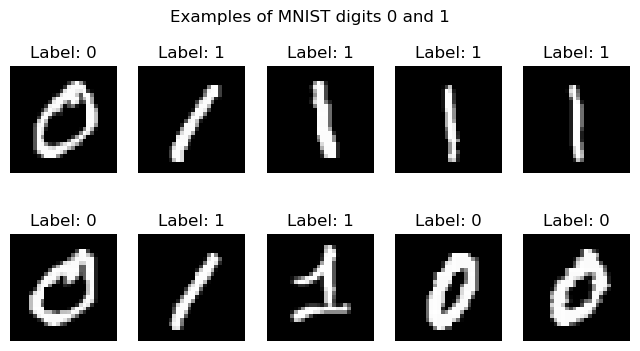

Shape after PCA : (14780, 2)
Explained variance ratio : [0.3218402 0.0902978]
Total explained variance : 0.41213799409684887


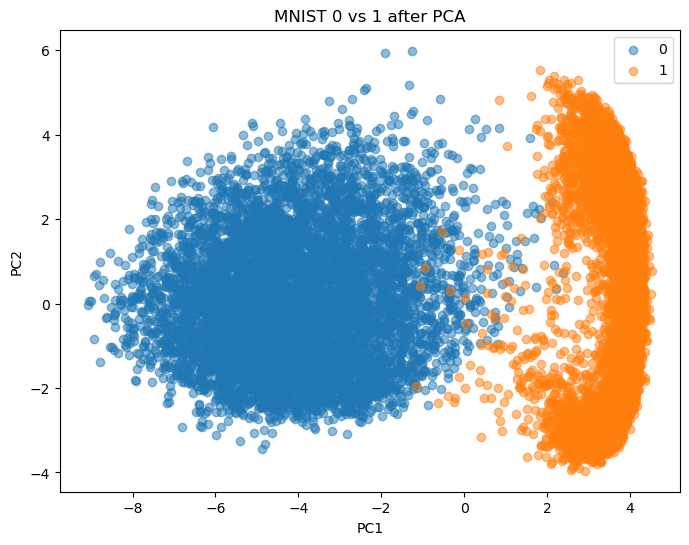

Train shape : (11824, 2)
Test shape : (2956, 2)
LDA model trained successfully.
Accuracy : 0.9878213802435724
Confusion Matrix :
[[1348   33]
 [   3 1572]]
Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1381
           1       0.98      1.00      0.99      1575

    accuracy                           0.99      2956
   macro avg       0.99      0.99      0.99      2956
weighted avg       0.99      0.99      0.99      2956

Mean of class 0 : [-4.02637823  0.04851153]
Mean of class 1 : [ 3.52740647 -0.04309055]
Distance between class means : 7.554340095428367

Fisher Criterion:
LDA cherche une direction qui maximise la séparation entre les classes
et minimise la dispersion à l'intérieur de chaque classe.


Bayes Rule:
LDA utilise une logique probabiliste.
Pour une nouvelle observation, le modèle estime la classe la plus probable
entre 0 et 1, puis choisit celle qui a la probabilité la plus élevée.



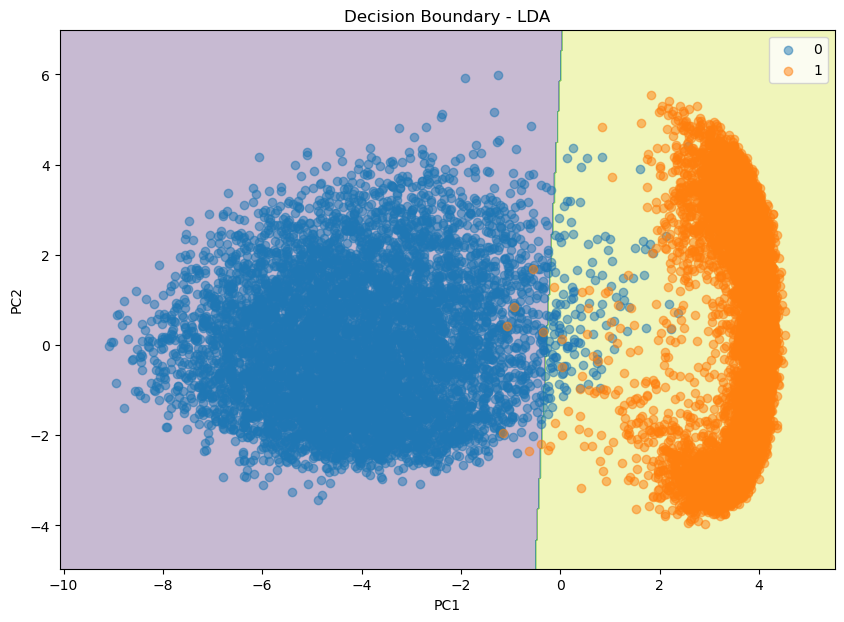


Interprétation finale:

Au départ, chaque image MNIST contient 784 variables correspondant aux pixels.
Nous avons d'abord gardé uniquement les chiffres 0 et 1.

Ensuite, nous avons appliqué PCA pour réduire les données à deux composantes principales:
PC1 et PC2. Cela permet de visualiser les images dans un plan 2D.

Après cette réduction, nous avons entraîné un modèle LDA.
Le modèle cherche une frontière linéaire qui sépare les deux classes.

Dans le graphique, les points de la classe 0 sont majoritairement à gauche,
alors que les points de la classe 1 sont majoritairement à droite.
Cela explique pourquoi la frontière de décision est presque verticale.

LDA se base sur le critère de Fisher pour maximiser la séparation entre les classes
et sur une logique probabiliste proche de la règle de Bayes pour choisir la classe
la plus probable.



In [1]:
# ==============================
# TP LDA - MNIST 0 vs 1
# ==============================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 1) Load MNIST dataset
print("Chargement du dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Shape X :", X.shape)
print("Shape y :", y.shape)


# 2) Keep only digits 0 and 1
mask = (y == 0) | (y == 1)

X_binary = X[mask]
y_binary = y[mask]

print("Shape after filtering 0 and 1 :", X_binary.shape)
print("Classes :", np.unique(y_binary))


# 3) Normalize pixel values
X_binary = X_binary / 255.0


# 4) Visualize some images
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_binary[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_binary[i]}")
    plt.axis("off")

plt.suptitle("Examples of MNIST digits 0 and 1")
plt.show()


# 5) Apply PCA to reduce dimension from 784 to 2
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_binary)

print("Shape after PCA :", X_pca.shape)
print("Explained variance ratio :", pca.explained_variance_ratio_)
print("Total explained variance :", np.sum(pca.explained_variance_ratio_))


# 6) Visualize data after PCA
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[y_binary == 0, 0],
    X_pca[y_binary == 0, 1],
    alpha=0.5,
    label="0"
)

plt.scatter(
    X_pca[y_binary == 1, 0],
    X_pca[y_binary == 1, 1],
    alpha=0.5,
    label="1"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("MNIST 0 vs 1 after PCA")
plt.legend()
plt.show()


# 7) Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print("Train shape :", X_train.shape)
print("Test shape :", X_test.shape)


# 8) Train LDA model
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

print("LDA model trained successfully.")


# 9) Prediction
y_pred = lda.predict(X_test)


# 10) Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)


# 11) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix :")
print(cm)


# 12) Classification Report
print("Classification Report :")
print(classification_report(y_test, y_pred))


# 13) Fisher Criterion explanation values
mean_0 = np.mean(X_train[y_train == 0], axis=0)
mean_1 = np.mean(X_train[y_train == 1], axis=0)

distance_between_means = np.linalg.norm(mean_1 - mean_0)

print("Mean of class 0 :", mean_0)
print("Mean of class 1 :", mean_1)
print("Distance between class means :", distance_between_means)

print("""
Fisher Criterion:
LDA cherche une direction qui maximise la séparation entre les classes
et minimise la dispersion à l'intérieur de chaque classe.
""")


# 14) Bayes Rule explanation
print("""
Bayes Rule:
LDA utilise une logique probabiliste.
Pour une nouvelle observation, le modèle estime la classe la plus probable
entre 0 et 1, puis choisit celle qui a la probabilité la plus élevée.
""")


# 15) Decision Boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = lda.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_pca[y_binary == 0, 0],
    X_pca[y_binary == 0, 1],
    alpha=0.5,
    label="0"
)

plt.scatter(
    X_pca[y_binary == 1, 0],
    X_pca[y_binary == 1, 1],
    alpha=0.5,
    label="1"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision Boundary - LDA")
plt.legend()
plt.show()


# 16) Final interpretation
print("""
Interprétation finale:

Au départ, chaque image MNIST contient 784 variables correspondant aux pixels.
Nous avons d'abord gardé uniquement les chiffres 0 et 1.

Ensuite, nous avons appliqué PCA pour réduire les données à deux composantes principales:
PC1 et PC2. Cela permet de visualiser les images dans un plan 2D.

Après cette réduction, nous avons entraîné un modèle LDA.
Le modèle cherche une frontière linéaire qui sépare les deux classes.

Dans le graphique, les points de la classe 0 sont majoritairement à gauche,
alors que les points de la classe 1 sont majoritairement à droite.
Cela explique pourquoi la frontière de décision est presque verticale.

LDA se base sur le critère de Fisher pour maximiser la séparation entre les classes
et sur une logique probabiliste proche de la règle de Bayes pour choisir la classe
la plus probable.
""")